In [1]:
#| code-fold: true
import json
from datetime import datetime
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import curve_fit

# Custom monotonic gray -> blue colormap, used in all plots below
gray_blue = LinearSegmentedColormap.from_list(
    'gray_blue', [(0.78, 0.78, 0.78), (0.10, 0.30, 0.65)])
BLUE = (0.10, 0.30, 0.65)

# Motivation

I started keeping a weekly running spreadsheet in December and noticed the numbers were drifting in the right direction: pace getting faster, HR lower at the same effort. It *felt* like I was getting fitter, but few months of subjective feel is not entirely reliable. So, I pulled my full Strava history (11 years, 803 runs) and tried to look at it more carefully.

Here, I'll focus on two questions: is my aerobic fitness actually improving (recently and over the long arc), and how has race pace progressed across distances over the last few years?

# Pulling Strava data

Strava has a public API. After the OAuth dance and a paginated pull through `/athlete/activities`, I had 803 runs back to 2014, 777 of them with HR data, although I only started running more seriously from 2023. The fetch script is short, just access-token refresh and saving everything to a single `activities.json`. I'll skip the fetch code in this post; here, I'm just loading the saved JSON.

Each activity comes with `start_date`, `distance`, `average_speed`, `average_heartrate`, `workout_type`, and a few other fields. The `workout_type` field is the most useful one for filtering. Strava lets you tag runs as `Race` (1), `Workout` (2), `Long Run` (3), or default/easy (`None` or `0`).

In [2]:
acts = json.loads(Path('activities.json').read_text())
runs = [a for a in acts if a.get('type') == 'Run']
with_hr = [a for a in runs if a.get('average_heartrate')]
print(f'Total activities: {len(acts)}')
print(f'Runs: {len(runs)}')
print(f'Runs with avg HR: {len(with_hr)}')
print(f'Date range: {min(a["start_date"][:10] for a in runs)} -> {max(a["start_date"][:10] for a in runs)}')

Total activities: 919
Runs: 803
Runs with avg HR: 777
Date range: 2014-11-04 -> 2026-05-05


# Aerobic fitness: easy-run HR vs pace

Same pace, lower HR is the textbook signal of improving aerobic fitness. Let's plot HR against pace, restricted to easy runs.

I filtered to `workout_type` in `{None, 0}`, excluded treadmill runs (HR data is unreliable indoors for me), and dropped runs longer than 15 mi (cardiac drift over long runs inflates HR and breaks the linear pace–HR relationship). Note that I also dropped runs shorter than 1 mi, since those tend to be warmups or interrupted runs.

Filtered easy runs: 604
Pace coef: -6.18 bpm per +1 min/mi slower
Drift:     -3.50 bpm/year at fixed pace
R^2:       0.531    resid std: 6.93 bpm


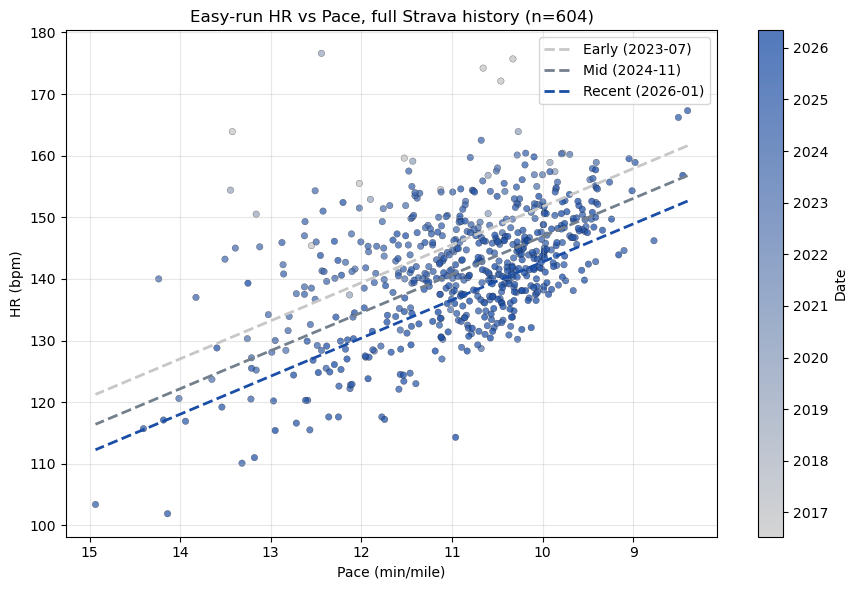

In [3]:
EASY_TYPES = {None, 0}
records = []
for a in acts:
    if a.get('type') != 'Run': continue
    if a.get('workout_type') not in EASY_TYPES: continue
    hr = a.get('average_heartrate')
    spd = a.get('average_speed')   # m/s
    dist_mi = a.get('distance', 0) / 1609.34
    if not hr or not spd or hr < 90 or hr > 200: continue
    pace = 26.8224 / spd            # min/mi
    if pace < 6 or pace > 15: continue
    if dist_mi < 1.0 or dist_mi > 15: continue
    if a.get('trainer'): continue
    records.append({
        'date': datetime.fromisoformat(a['start_date'].replace('Z','+00:00')).date(),
        'pace': pace,
        'hr': hr,
    })
records.sort(key=lambda r: r['date'])
print(f'Filtered easy runs: {len(records)}')

dates = np.array([mdates.date2num(r['date']) for r in records])
paces = np.array([r['pace'] for r in records])
hrs   = np.array([r['hr'] for r in records])

# Multivariate linear: HR ~ pace + date
X = np.column_stack([paces, dates, np.ones_like(paces)])
coef, *_ = np.linalg.lstsq(X, hrs, rcond=None)
a_, b_, c_ = coef
resid = hrs - X @ coef
print(f'Pace coef: {a_:.2f} bpm per +1 min/mi slower')
print(f'Drift:     {b_*365:+.2f} bpm/year at fixed pace')
print(f'R^2:       {1 - resid.var()/hrs.var():.3f}    resid std: {resid.std():.2f} bpm')

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(paces, hrs, c=dates, cmap=gray_blue, s=22,
                edgecolor='k', linewidth=0.2, alpha=0.75)
cbar = plt.colorbar(sc, ax=ax)
loc = mdates.AutoDateLocator(); cbar.ax.yaxis.set_major_locator(loc)
cbar.ax.yaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
cbar.set_label('Date')
for q, color, lbl in [(0.10, (0.78, 0.78, 0.78), 'Early'),
                      (0.50, (0.45, 0.50, 0.55), 'Mid'),
                      (0.90, (0.10, 0.30, 0.65), 'Recent')]:
    qd = np.percentile(dates, q*100)
    xs = np.linspace(paces.min(), paces.max(), 50)
    ax.plot(xs, a_*xs + b_*qd + c_, '--', color=color, lw=2,
            label=f'{lbl} ({mdates.num2date(qd):%Y-%m})')
ax.invert_xaxis()
ax.set_xlabel('Pace (min/mile)'); ax.set_ylabel('HR (bpm)')
ax.set_title(f'Easy-run HR vs Pace, full Strava history (n={len(records)})')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

Three regression lines (early, mid, recent) share a similar pace–HR slope but stack with progressively lower intercepts. At every pace, recent HR is meaningfully below early HR.

The time-series view makes the trajectory clearer if I normalize HR to a fixed reference pace (9:30/mi) using the regression coefficient above, then plot a 90-day rolling median:

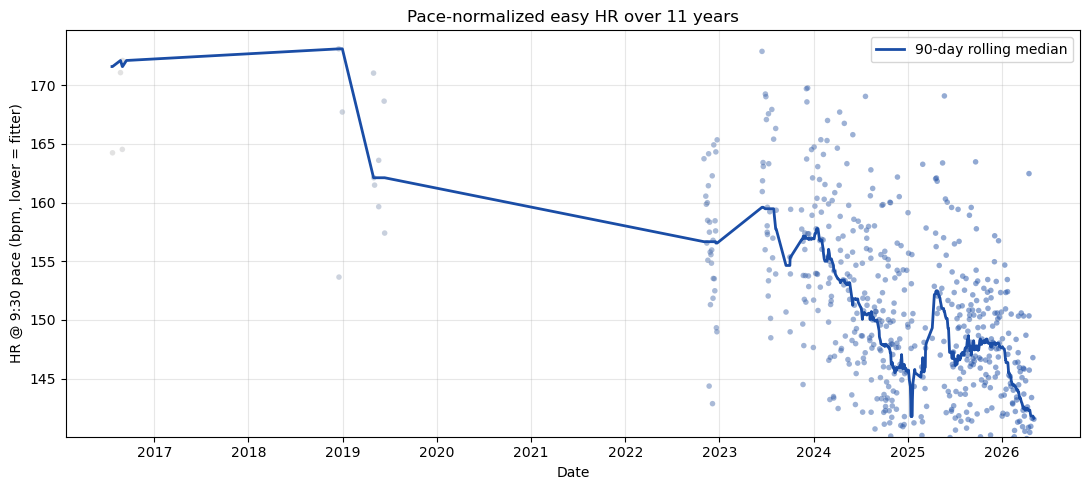

Year   HR @ 9:30   n
2016     175.1        8
2018     173.1        5
2019     162.1        7
2022     156.7       32
2023     157.4       58
2024     150.4      225
2025     148.0      195
2026     143.5       74


In [4]:
ref_pace = 9.5
hr_norm = hrs - a_ * (paces - ref_pace)

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter([r['date'] for r in records], hr_norm, c=dates, cmap=gray_blue,
           s=16, alpha=0.5, edgecolor='none')
order = np.argsort(dates); t_s, h_s = dates[order], hr_norm[order]
window = 90
roll_x, roll_y = [], []
for i in range(len(t_s)):
    mask = (t_s >= t_s[i]-window/2) & (t_s <= t_s[i]+window/2)
    if mask.sum() >= 5:
        roll_x.append(t_s[i]); roll_y.append(np.median(h_s[mask]))
ax.plot([mdates.num2date(x) for x in roll_x], roll_y,
        color=BLUE, lw=2, label='90-day rolling median')
ax.set_ylabel('HR @ 9:30 pace (bpm, lower = fitter)')
ax.set_xlabel('Date')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Pace-normalized easy HR over 11 years')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

# Yearly medians at 9:30
print('Year   HR @ 9:30   n')
for y in sorted({r['date'].year for r in records}):
    mask = np.array([r['date'].year == y for r in records])
    if mask.sum() < 3: continue
    print(f'{y}    {np.median(hr_norm[mask]):6.1f}     {mask.sum():4d}')

Wow, that's about a 32 bpm drop over a decade at the same pace. In 2017, I ran a turkey trot with my kids and I only trained few weeks, then stopped. In 2019, I moved to Los Angeles, and tried running, but I switched over to cycling because running sucked at the time (I wasn't in shape for running). I again started running in 2023, and kept going. I was running/walking in the beginning, but consistency helped. I broke my ankle at the end of 2023, but kept running after the recovery. Consistency does pay off. 

The same pattern shows up in just the recent ~10 weeks of my training spreadsheet, where a multivariate `HR ~ pace + date` fit gives roughly −0.9 bpm/month at fixed pace. So, the long-arc trend is not just a decade-old story; it is still going.

# Volume and average pace

Above is filtered to easy runs. It might also be informative to look at total distance and average pace by year, across all runs.

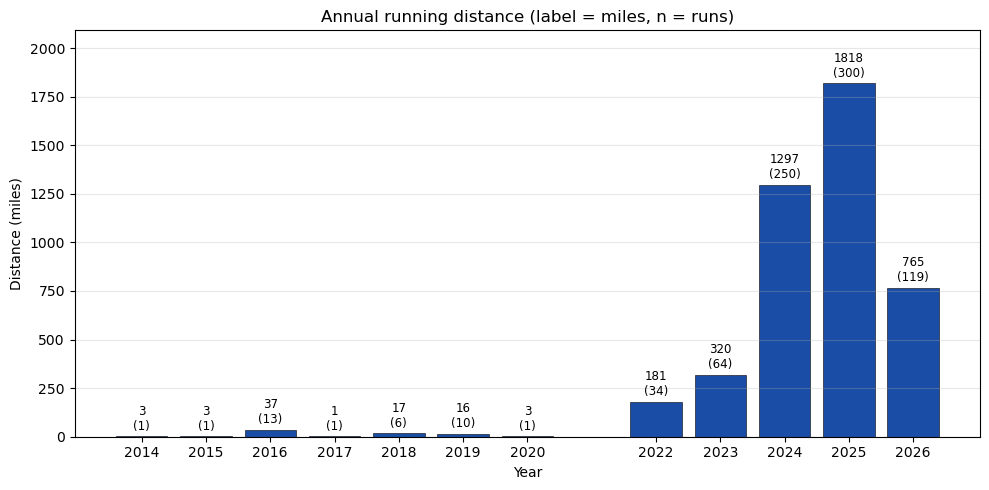

In [5]:
year_dist = defaultdict(float)        # miles
year_time = defaultdict(float)        # seconds (moving)
year_count = defaultdict(int)
year_dist_easy = defaultdict(float)
year_time_easy = defaultdict(float)

for a in acts:
    if a.get('type') != 'Run': continue
    if a.get('manual'): continue
    dist_mi = a.get('distance', 0) / 1609.34
    mtime = a.get('moving_time', 0)
    if dist_mi <= 0 or mtime <= 0: continue
    year = datetime.fromisoformat(a['start_date'].replace('Z','+00:00')).year
    year_dist[year] += dist_mi
    year_time[year] += mtime
    year_count[year] += 1
    if a.get('workout_type') in (None, 0):
        year_dist_easy[year] += dist_mi
        year_time_easy[year] += mtime

years = sorted(year_dist)
dist = [year_dist[y] for y in years]
counts = [year_count[y] for y in years]
pace_easy = [year_time_easy[y]/60 / year_dist_easy[y] if year_dist_easy[y] > 0 else None for y in years]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(years, dist, color=BLUE, edgecolor='k', linewidth=0.4)
for x, y_, n in zip(years, dist, counts):
    ax.text(x, y_+max(dist)*0.01, f'{y_:.0f}\n({n})', ha='center', va='bottom',
            fontsize=8.5, color='k')
ax.set_xlabel('Year'); ax.set_ylabel('Distance (miles)')
ax.set_title('Annual running distance (label = miles, n = runs)')
ax.set_xticks(years); ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, max(dist)*1.15)
plt.tight_layout()
plt.show()

Late 2023 is when I jumped from running ~5 mi/week to ~25 mi/week, then roughly doubled again in 2024. 2025 finished at 1818 mi; 2026 is on pace for ~2200.

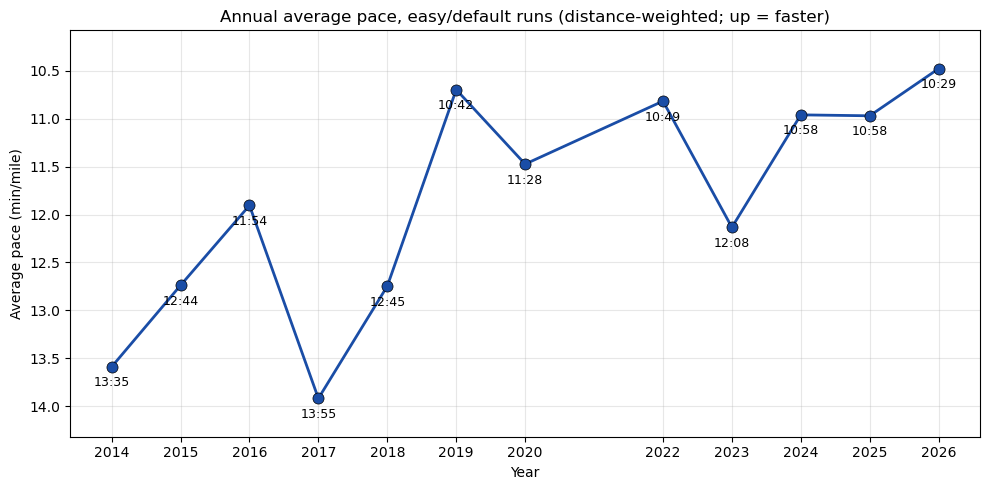

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
easy_pace = np.array([p if p is not None else np.nan for p in pace_easy], dtype=float)
ax.plot(years, easy_pace, '-o', color=BLUE, lw=2, ms=8, mec='k', mew=0.5)
for y, p, n in zip(years, easy_pace, counts):
    if np.isnan(p): continue
    m = int(p); s = int(round((p-m)*60))
    ax.annotate(f'{m}:{s:02d}', xy=(y, p), xytext=(0, -14),
                textcoords='offset points', ha='center', fontsize=9)
ax.set_xlabel('Year'); ax.set_ylabel('Average pace (min/mile)')
ax.set_title('Annual average pace, easy/default runs (distance-weighted; up = faster)')
ax.set_xticks(years)
ymin = np.nanmin(easy_pace) - 0.4
ymax = np.nanmax(easy_pace) + 0.4
ax.set_ylim(ymax, ymin)  # invert so up = faster
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Annual average pace was actually *slower* during the high-volume ramp years (10:58 in 2024–2025) than during a lower-volume 2019. That's because the new volume came in mostly at easy pace. But 2026 has dropped to 10:29. Same volume, run faster.

# Race pace progression

Easy-run HR is a leading indicator; race times are the ground truth. Strava lets me filter `workout_type == 1` (Race), and after dropping a few activities where I was pacing someone else (not my own effort), I had 11 races across 2024–2026.

The empirical relationship between race pace and distance is roughly logarithmic. Pace gets slower at longer distances, but the falloff slows down. Let's fit `pace = a + b·log10(distance)` per year and see what changes.

Races kept: 12

Per-year log fits: pace = a + b*log10(distance)
  2024 (n=3): a=7.52  b=+3.15  pace@5K=9.07  pace@HM=11.04  pace@M=11.98  R^2=0.99
  2025 (n=5): a=6.60  b=+3.08  pace@5K=8.12  pace@HM=10.04  pace@M=10.97  R^2=0.90
  2026 (n=3): a=6.00  b=+2.96  pace@5K=7.46  pace@HM=9.32  pace@M=10.21  R^2=0.91


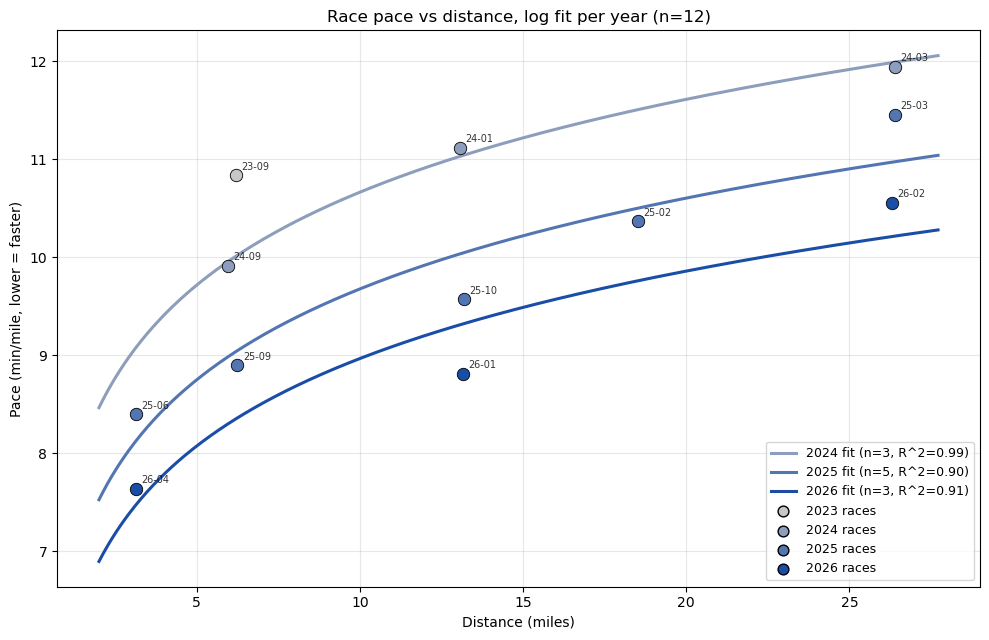

In [7]:
def log_curve(d, a, b):
    return a + b * np.log10(d)

# Races where I was pacing someone else, not my own effort
PACING_RUNS = {
    '2026-03-01', '2026-03-08', '2025-11-27', '2025-07-27',
    '2025-04-27', '2025-03-15', '2025-05-17',
}

races = []
for a in acts:
    if a.get('type') != 'Run' or a.get('workout_type') != 1: continue
    spd = a.get('average_speed')
    dist_mi = a.get('distance', 0) / 1609.34
    if not spd or dist_mi <= 0: continue
    pace = 26.8224 / spd
    date_str = a['start_date'][:10]
    if date_str in PACING_RUNS: continue
    if pace > 13: continue
    races.append({
        'date': datetime.fromisoformat(a['start_date'].replace('Z','+00:00')).date(),
        'year': datetime.fromisoformat(a['start_date'].replace('Z','+00:00')).year,
        'dist': dist_mi,
        'pace': pace,
        'name': a.get('name',''),
    })
races.sort(key=lambda r: r['date'])
print(f'Races kept: {len(races)}')

year_fits = {}
print('\nPer-year log fits: pace = a + b*log10(distance)')
for yr in sorted({r['year'] for r in races}):
    rs = [r for r in races if r['year'] == yr]
    if len(rs) < 2: continue
    d = np.array([r['dist'] for r in rs])
    p = np.array([r['pace'] for r in rs])
    po, _ = curve_fit(log_curve, d, p, maxfev=20000)
    pred = log_curve(d, *po)
    r2 = 1 - (p - pred).var() / p.var() if len(p) > 2 else 1.0
    year_fits[yr] = (po, r2, len(rs))
    print(f'  {yr} (n={len(rs)}): a={po[0]:.2f}  b={po[1]:+.2f}  '
          f'pace@5K={log_curve(3.107,*po):.2f}  pace@HM={log_curve(13.11,*po):.2f}  '
          f'pace@M={log_curve(26.22,*po):.2f}  R^2={r2:.2f}')

years_set = sorted({r['year'] for r in races})
y_min, y_max = min(years_set), max(years_set)
def year_color(y):
    return gray_blue((y - y_min) / max(1, y_max - y_min))

fig, ax = plt.subplots(figsize=(10, 6.5))
for r in races:
    ax.scatter(r['dist'], r['pace'], color=year_color(r['year']), s=80,
               edgecolor='k', linewidth=0.6, zorder=3)
    ax.annotate(f"{r['date']:%y-%m}", xy=(r['dist'], r['pace']),
                xytext=(4, 4), textcoords='offset points', fontsize=7, alpha=0.8)
xs = np.linspace(2, max(r['dist'] for r in races)*1.05, 400)
for yr, (po, r2y, n) in year_fits.items():
    label = f'{yr} fit (n={n}'
    if n > 2: label += f', R^2={r2y:.2f}'
    label += ')'
    ax.plot(xs, log_curve(xs, *po), '-', color=year_color(yr), lw=2.2, label=label)
for yr in years_set:
    ax.scatter([], [], color=year_color(yr), s=60, edgecolor='k', label=f'{yr} races')
ax.set_xlabel('Distance (miles)')
ax.set_ylabel('Pace (min/mile, lower = faster)')
ax.set_title(f'Race pace vs distance, log fit per year (n={len(races)})')
ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

Two things stood out. First, the slopes (b ≈ 3.0) are nearly identical across years, so the *shape* of how I handle distance isn't really changing; the whole curve is shifting downward as base fitness improves. Second, improvement is roughly uniform across distances, about 45–60 sec/mi gained per year at every distance. So this is not a "got faster at 5K but lost the marathon" story, or vice versa, although my marathon time is much slower than what my 5K/half time predicts. So, there's a room for an improvement.

# Conclusion

The two questions I started with both have a clear answer. Easy-run HR at fixed pace is the lowest it has ever been and still trending down, even just over the past few months. Race pace has dropped roughly 45–60 sec/mi per year at every distance from 5K through marathon, and the log-curve shape has stayed consistent across years.

A few things I find interesting and would like to dig into more:

- The Riegel formula `T_2 = T_1 * (D_2/D_1)^1.06` predicts a marathon ~13% faster than I actually run, given my recent 5K. The half-marathon is also slower than predicted, but the gap is much smaller. I suspect this is muscular endurance / fueling and not aerobic capacity (race-day HR was lower at the marathon than at the half, which is the opposite of what an aerobic limit would look like), but I would like to look at this more carefully.
- The `workout_type` labels are not always reliable. Some runs tagged `easy` in the data are clearly tempo runs based on HR. A cleaner pass over the data, or a model that infers workout type from pace/HR distribution within the activity, would probably tighten the regressions.
- I just started a 16 week 5K training block. It would be interesting to run this every few months or so to keep track if I'm improving and look for a bottleneck in my training.